In [3]:
pip install opencv-python

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import os
import cv2
import seaborn as sns
import pickle

In [7]:
# ✅ Step 1: Set Up Data Generators
train_dir = r"C:\Users\sreek\Downloads\archive\train"  # Update with your dataset path
val_dir = r"C:\Users\sreek\Downloads\archive\test"  # Update with your dataset path
test_dir = r"C:\Users\sreek\Downloads\archive\test"  # Update with your dataset path

batch_size = 32
img_size = (224, 224)

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'  # One-hot encoding
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=1,  # Batch size 1 for individual prediction
    class_mode='categorical',
    shuffle=False
)


Found 5723 images belonging to 4 classes.
Found 1430 images belonging to 4 classes.
Found 1430 images belonging to 4 classes.


In [6]:
Labels = ['glioma','meningioma','pituitary','notumor']
img_size=224
def get_data(dataset):
    data=[]
    for label in Labels:
        path=os.path.join(dataset,label)
        db_class=Labels.index(label)
        print(db_class)
        i=1
        for img in os.listdir(path):
            try:
                arr_img=cv2.imread(os.path.join(path,img))
                im=arr_img;

                arr_resized=cv2.resize(im,(img_size,img_size))
                if im is None:
                    print('hoooi')
                i=i+1

                data.append([arr_resized, db_class])



            except Exception as e:
                print(e)
                continue



    return (np.array(data, dtype=object))


In [7]:
datadir = r"C:\Users\sreek\Downloads\archive\train"

train = get_data(datadir)

0
1
2
3


<Axes: xlabel='count'>

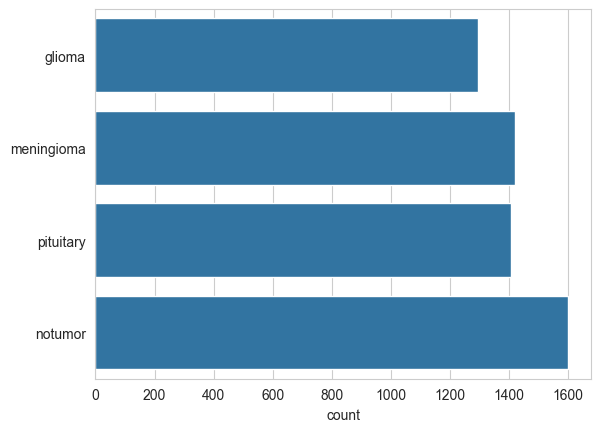

In [8]:
l=[]
for i in train:
  if (i[1]==0):
    l.append('glioma')
  elif(i[1] == 1):
    l.append("meningioma")
  elif(i[1] == 2):
    l.append("pituitary")
  else:
     l.append("notumor")
sns.set_style('whitegrid')
sns.countplot(l)

786432


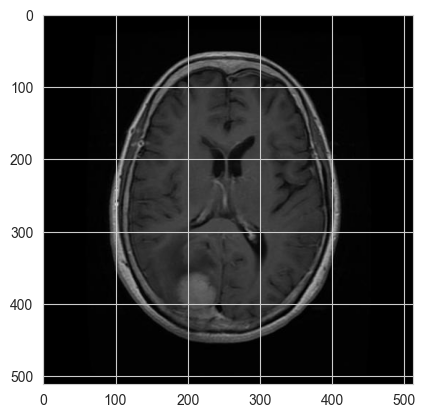

In [9]:
img_data = []
img_size=224
path =r"C:\Users\sreek\Downloads\archive\train\meningioma\me-0006.jpg"
arr_img=cv2.imread(path)
try:
                spo= path.find('-')
                arr_img=cv2.imread(path)
                im=arr_img;
                plt.imshow(im)
                arr_resized=cv2.resize(im,(img_size,img_size))
                print(arr_img.size)
                epo= path.find('-',spo+1)
                ex=path[spo+1:epo]
                ex=ex[:2]
                if im is None:
                    print('hoooi')
                i=i+1

                img_data.append(arr_resized)


except Exception as e:
      print('ddd')
      print(e)
test_array = np.array(img_data, dtype=object)

In [10]:
from tensorflow.keras.regularizers import l2

In [11]:
# ✅ Step 2: Load Pretrained Model (DenseNet121)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze pretrained layers

# ✅ Step 3: Add Custom Layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(len(train_generator.class_indices), activation='softmax')(x)  # Output layer

model = Model(inputs=base_model.input, outputs=output_layer)

# ✅ Step 4: Compile Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


In [12]:
def fuse_conv_bn(conv_layer, bn_layer):
    """Fuses a Conv2D layer and BatchNormalization layer into a single Conv2D layer."""
    # Extract convolution weights and biases
    conv_weights = conv_layer.get_weights()[0]  # Shape: (kernel_h, kernel_w, in_channels, out_channels)
    conv_bias = conv_layer.get_weights()[1] if len(conv_layer.get_weights()) > 1 else np.zeros(conv_weights.shape[-1])

    # Extract batch normalization parameters
    bn_gamma, bn_beta, bn_mean, bn_var = bn_layer.get_weights()
    bn_epsilon = bn_layer.epsilon

    # Compute scale and bias correction 
    scale = bn_gamma / np.sqrt(bn_var + bn_epsilon)
    bias = bn_beta - (bn_mean * scale)

    # Update conv weights
    fused_weights = conv_weights * scale.reshape((1, 1, 1, -1))
    fused_bias = conv_bias * scale + bias

    # Create a new Conv2D layer with fused weights
    fused_conv = Conv2D(filters=conv_layer.filters,
                        kernel_size=conv_layer.kernel_size,
                        strides=conv_layer.strides,
                        padding=conv_layer.padding,
                        dilation_rate=conv_layer.dilation_rate,
                        activation=conv_layer.activation,
                        use_bias=True, kernel_regularizer=l2(0.01))  # Bias is needed after fusion
    # regularisation over
    # Set new weights
    input_shape = (1, 224, 224, 3) 
    fused_conv.build(input_shape)  # Build layer with correct shape
    fused_conv.set_weights([fused_weights, fused_bias])

    return fused_conv


In [13]:
def quantise(model):
    quantized_model = tfmot.quantization.keras.quantize_model(model)
    # Compile the quantized model
    return(quantized_model)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [15]:
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout, BatchNormalization

In [16]:
 # Define a Conv2D layer for a 224x224 image with 3 channels (RGB)
conv = Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(1,224, 224, 3))
#conv = Conv2D(32, (3, 3), padding='same', use_bias=False, input_shape=(224, 224, 3))
bn = BatchNormalization()
# Fuse layers
fused_conv = model #fuse_conv_bn(conv, bn)
    
# Print fused layer summary
    # fusing of Convlution Layer and BN -ok 
    # Tuning
    # 1.Output Kenel Regularation
    #2. Quantisation
    # Selef attension 
    
    #q_model= quantise (fused_conv)
q_model=fused_conv
# Step 5: Train the Model
epochs = 10
history = q_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,     callbacks=[early_stopping]
)

#  Step 6: Save the Model
#model.save("image_classifier.h5")

model.save("Models/brain_tumor_model_V2.keras")
# Step 7: Load the Model for Predictions
#loaded_model = keras.models.load_model("image_classifier.h5")
print("Model saved successfully!")



Epoch 1/10
179/179 [==============================] - 682s 4s/step - loss: 0.9054 - accuracy: 0.6325 - precision: 0.7190 - recall: 0.5315 - val_loss: 0.5168 - val_accuracy: 0.8378 - val_precision: 0.8780 - val_recall: 0.7748
Epoch 2/10
179/179 [==============================] - 615s 3s/step - loss: 0.5539 - accuracy: 0.7889 - precision: 0.8345 - recall: 0.7349 - val_loss: 0.4446 - val_accuracy: 0.8483 - val_precision: 0.8790 - val_recall: 0.8126
Epoch 3/10
179/179 [==============================] - 636s 4s/step - loss: 0.4685 - accuracy: 0.8282 - precision: 0.8619 - recall: 0.7828 - val_loss: 0.4118 - val_accuracy: 0.8615 - val_precision: 0.8858 - val_recall: 0.8350
Epoch 4/10
179/179 [==============================] - 632s 4s/step - loss: 0.4295 - accuracy: 0.8448 - precision: 0.8738 - recall: 0.8132 - val_loss: 0.3722 - val_accuracy: 0.8699 - val_precision: 0.8975 - val_recall: 0.8448
Epoch 5/10
179/179 [==============================] - 611s 3s/step - loss: 0.4120 - accuracy: 0.8503

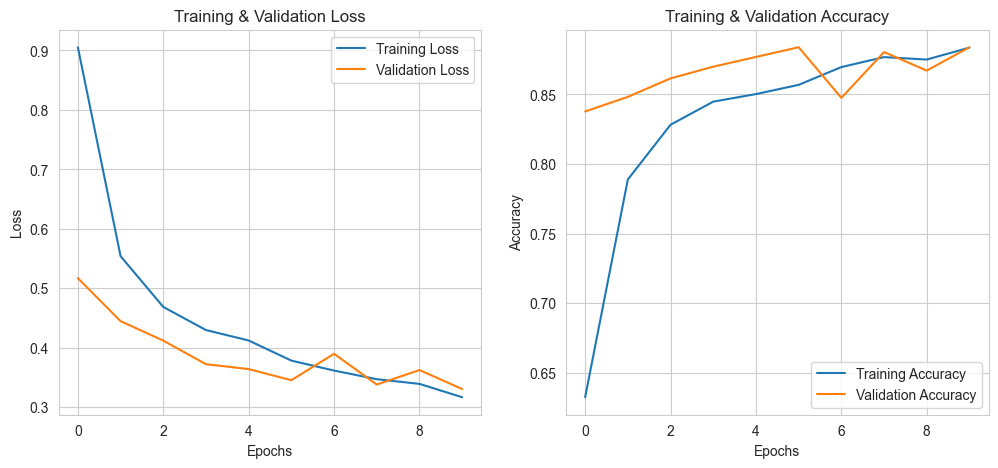

In [18]:
import matplotlib.pyplot as plt

# Extract values from history
history_dict = history.history
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs_range = range(len(train_loss))

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.show()


# Extract history and plot recall/precision
history_dict = history.history
epochs_range = range(len(history_dict['loss']))

# Get precision and recall
train_precision = history_dict['precision']
val_precision = history_dict['val_precision']
train_recall = history_dict['recall']
val_recall = history_dict['val_recall']



In [19]:
from tensorflow.keras.models import load_model

loaded_model = load_model("Models/brain_tumor_model_V2.keras")

In [9]:
# Step 8: Make Predictions

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load your saved model
loaded_model = load_model("Models/brain_tumor_model_V2.keras")

# Prediction function
def predict_image(image_path, model, class_labels):
    
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Image: {os.path.basename(image_path)}")
    print(f"Predicted Class: {class_labels[predicted_class]}")
    print(f"Confidence: {confidence:.2f}")
    print("-" * 40)

    return predicted_class


# Get class labels from generator
class_labels = {v: k for k, v in train_generator.class_indices.items()}

print("Class Labels:", class_labels)


# Folder path for testing
path = r"C:\Users\sreek\Downloads\archive\test\glioma"

# Counters
a1 = 0
a2 = 0
a3 = 0
a4 = 0


# Predict all images in folder
for img_name in os.listdir(path):

    test_image_path = os.path.join(path, img_name)

    cls = predict_image(test_image_path, loaded_model, class_labels)

    if cls == 0:
        a1 += 1

    elif cls == 1:
        a2 += 1

    elif cls == 2:
        a3 += 1

    elif cls == 3:
        a4 += 1


# Final counts
print("\nPrediction Counts:")
print("Class 0:", a1)
print("Class 1:", a2)
print("Class 2:", a3)
print("Class 3:", a4)

Class Labels: {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}
Image: gl-0013.jpg
Predicted Class: glioma
Confidence: 0.96
----------------------------------------
Image: gl-0021.jpg
Predicted Class: glioma
Confidence: 0.94
----------------------------------------
Image: gl-0028.jpg
Predicted Class: glioma
Confidence: 0.94
----------------------------------------
Image: gl-0036.jpg
Predicted Class: glioma
Confidence: 0.86
----------------------------------------
Image: gl-0038.jpg
Predicted Class: glioma
Confidence: 0.99
----------------------------------------
Image: gl-0046.jpg
Predicted Class: glioma
Confidence: 0.99
----------------------------------------
Image: gl-0048.jpg
Predicted Class: glioma
Confidence: 0.99
----------------------------------------
Image: gl-0054.jpg
Predicted Class: glioma
Confidence: 0.43
----------------------------------------
Image: gl-0055.jpg
Predicted Class: glioma
Confidence: 0.52
----------------------------------------
Image: gl-0060.j

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset generator
test_generator.reset()

# Get predictions
pred_probs = model.predict(test_generator)

# Predicted classes
y_pred = np.argmax(pred_probs, axis=1)

# True classes
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))